<a href="https://colab.research.google.com/github/vinayagarwal5/fullStackDatascience/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Tue Aug 18 04:09:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from matplotlib import pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the package to lable the images & it will automatically lable all the images

In [6]:
img = image.load_img('/content/drive/MyDrive/CNN/training/sad/joseph-gonzalez-XiglXNewuV0-unsplash.jpg')

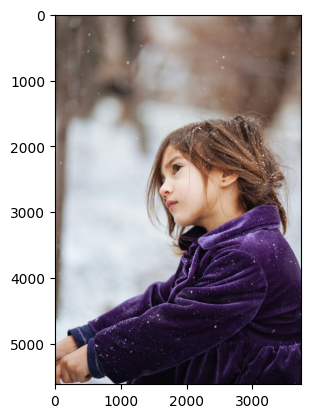

In [10]:
img.info

{'jfif': 258,
 'jfif_version': (1, 2),
 'dpi': (72, 72),
 'jfif_unit': 1,
 'jfif_density': (72, 72),
 'progressive': 1,
 'progression': 1,
 'icc_profile': b'\x00\x00\x0cHLino\x02\x10\x00\x00mntrRGB XYZ \x07\xce\x00\x02\x00\t\x00\x06\x001\x00\x00acspMSFT\x00\x00\x00\x00IEC sRGB\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xf6\xd6\x00\x01\x00\x00\x00\x00\xd3-HP  \x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x11cprt\x00\x00\x01P\x00\x00\x003desc\x00\x00\x01\x84\x00\x00\x00lwtpt\x00\x00\x01\xf0\x00\x00\x00\x14bkpt\x00\x00\x02\x04\x00\x00\x00\x14rXYZ\x00\x00\x02\x18\x00\x00\x00\x14gXYZ\x00\x00\x02,\x00\x00\x00\x14bXYZ\x00\x00\x02@\x00\x00\x00\x14dmnd\x00\x00\x02T\x00\x00\x00pdmdd\x00\x00\x02\xc4\x00\x00\x00\x88vued\x00\x00\x03L\x00\x00\x00\x86view\x00\x00\x03\xd4\x00\x00\x00$lumi\x00\x00\x03\xf8\x00\x00\x00\x14meas\x00\x00\x04\x0c\x00\x00\

In [13]:
i1 = cv2.imread('/content/drive/MyDrive/CNN/training/sad/joseph-gonzalez-XiglXNewuV0-unsplash.jpg')

In [15]:
i1.shape

(5616, 3744, 3)

In [12]:
train = ImageDataGenerator(rescale=1/200)
validation = ImageDataGenerator(rescale=1/200)
#to scale all the images i need to divide with 255

In [14]:
train_dataset = train.flow_from_directory('/content/drive/MyDrive/CNN/training',
                                         target_size=(200,200),
                                         batch_size=3,
                                         class_mode='binary')
validation_dataset = train.flow_from_directory('/content/drive/MyDrive/CNN/validation',
                                         target_size=(200,200),
                                         batch_size=3,
                                         class_mode='binary')

Found 16 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [16]:
train_dataset.class_indices

{'happy': 0, 'sad': 1}

In [17]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int32)

In [19]:
#now we will analyzing maxpooling
model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3),activation='relu',
                                                           input_shape=(200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2),#3 filter we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation= 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation= 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512,activation='relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation='sigmoid')
                                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [22]:
model_fit = model.fit(train_dataset,epochs=20)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5625 - loss: 5.6708
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 658ms/step - accuracy: 0.7500 - loss: 0.8132
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 918ms/step - accuracy: 0.6250 - loss: 0.6886
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 586ms/step - accuracy: 0.7500 - loss: 0.5972
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 621ms/step - accuracy: 0.8125 - loss: 0.4937
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 793ms/step - accuracy: 0.9375 - loss: 0.1798
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 659ms/step - accuracy: 0.8750 - loss: 0.3802
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 571ms/step - accuracy: 1.0000 - loss: 0.0686
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 878ms/step - accuracy: 1.0000 - loss: 0.0232
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 889ms/step - accuracy: 1.0000 - loss: 0.0075
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 677ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 909ms/step - accuracy: 1.0000 - loss

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,764 (132.44 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,358,883 (66.22 MB)

In [26]:
dir_path = '/content/drive/MyDrive/CNN/testing'
for i in os.listdir(dir_path):
    print(i)

amaury-gutierrez-sbls-P3wvP4-unsplash.jpg
arwan-sutanto-Q_LiPtuYv1Y-unsplash.jpg
Alone-Sad-Kid.jfif
Alone-Sad-Girl.jfif
images-3.jfif
images-4.jfif
images-11.jfif
images-12.jfif
images-13.jfif
images-14.jfif
depositphotos_249566606-stock-photo-happy-cheerful-young-woman.jpg
images-15.jfif
images=19.jfif
four-yellow-felt-flowers-with-smiley-faces-on-them-photo.jpg


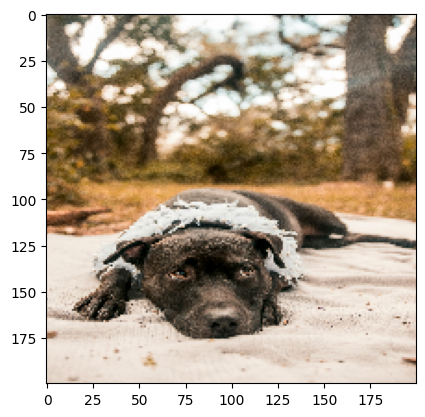

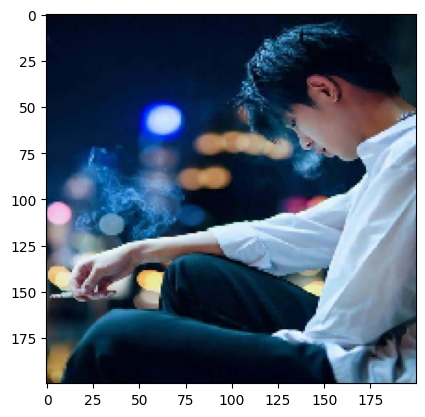

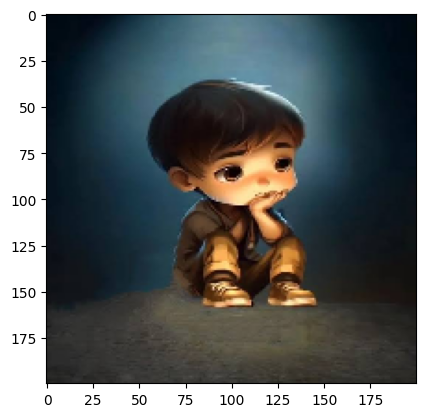

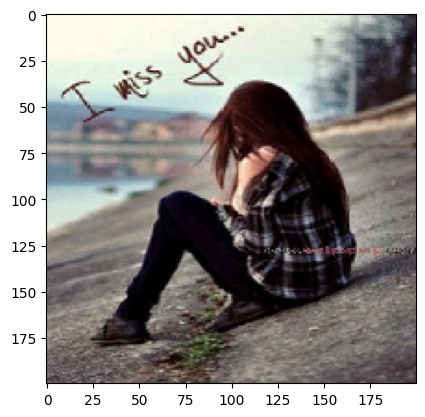

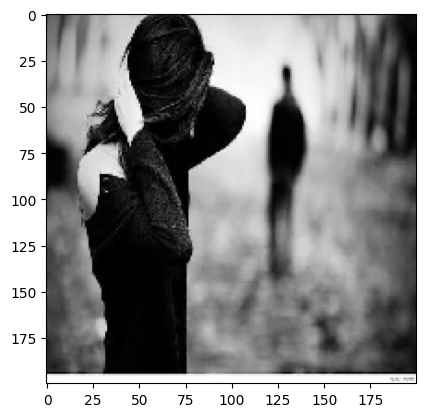

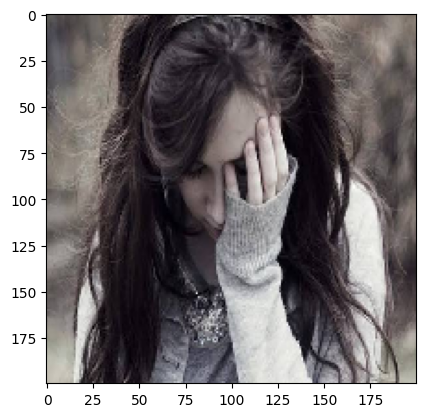

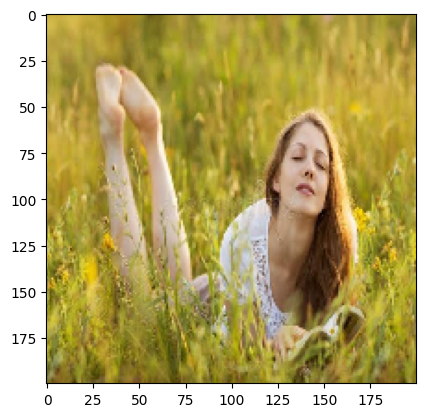

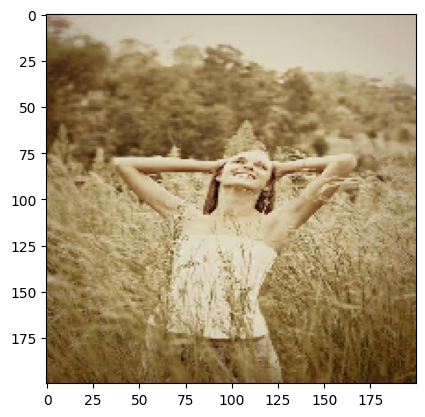

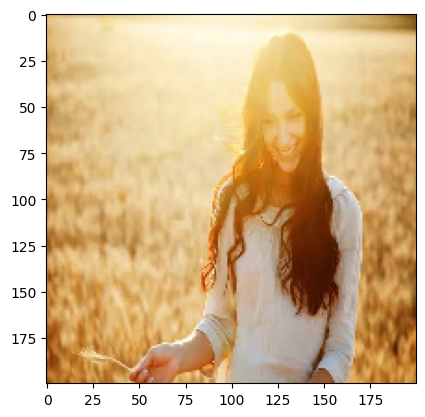

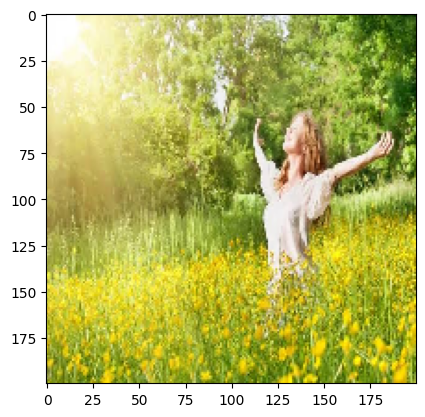

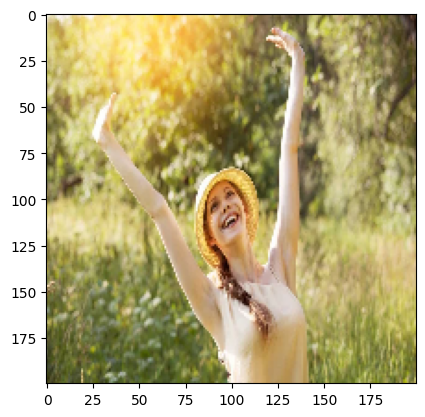

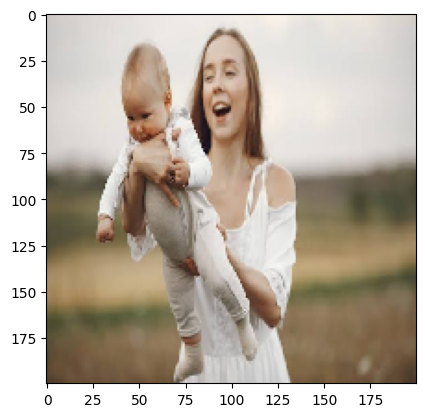

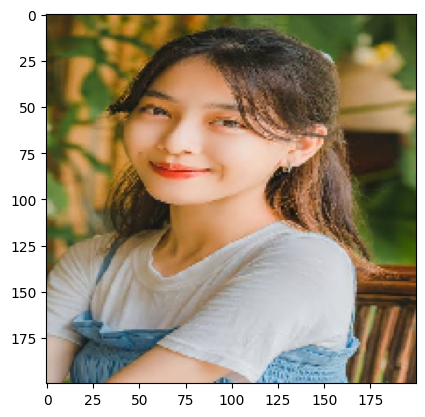

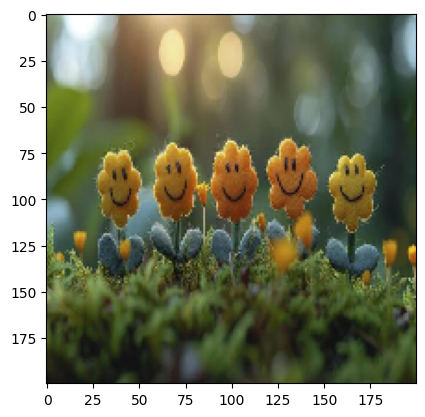

In [27]:
dir_path = '/content/drive/MyDrive/CNN/testing'
for i in os.listdir(dir_path):
    img = image.load_img(dir_path+ '//'+i, target_size= (200,200))
    plt.imshow(img)
    plt.show()

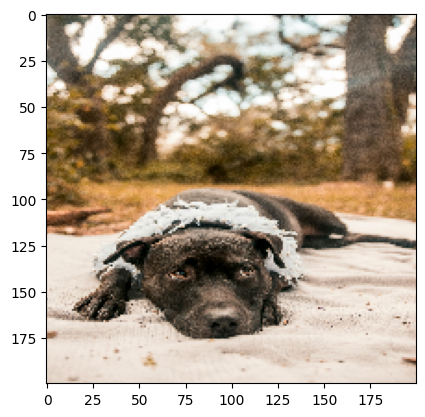

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
I am sad


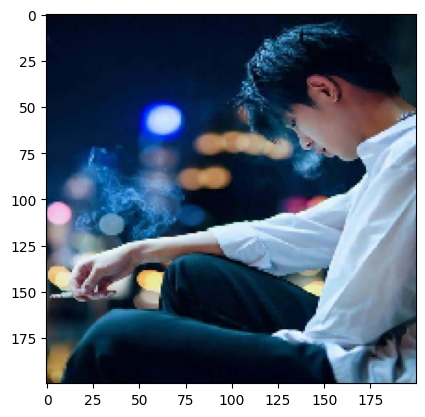

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
I am sad


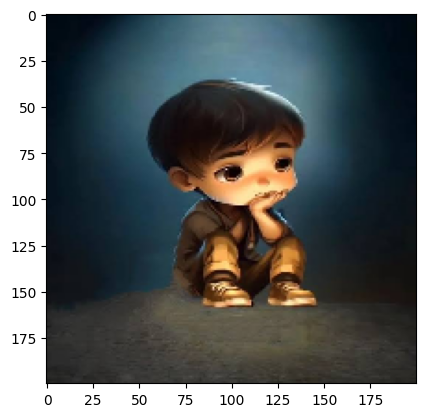

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
I am happy


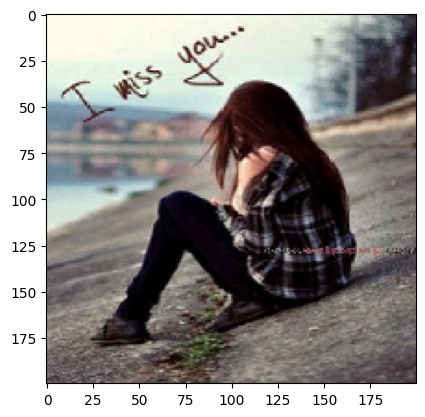

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
I am happy


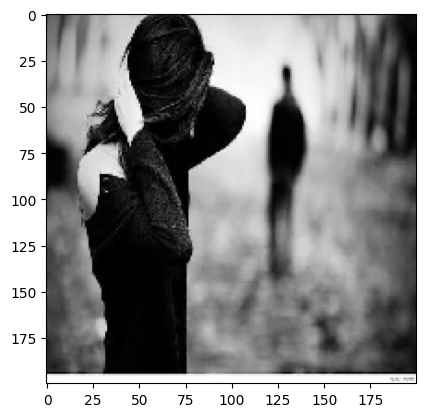

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
I am happy


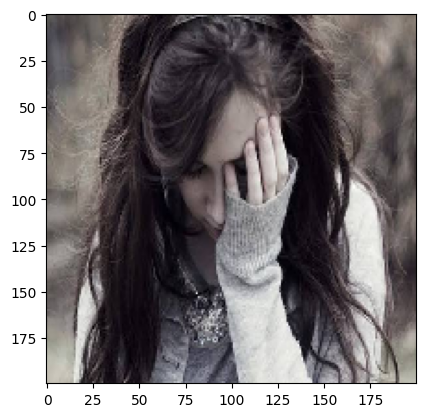

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
I am happy


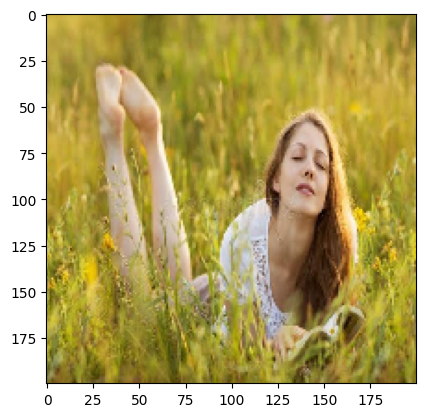

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
I am happy


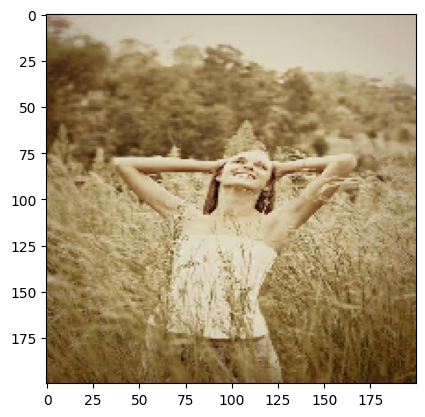

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
I am happy


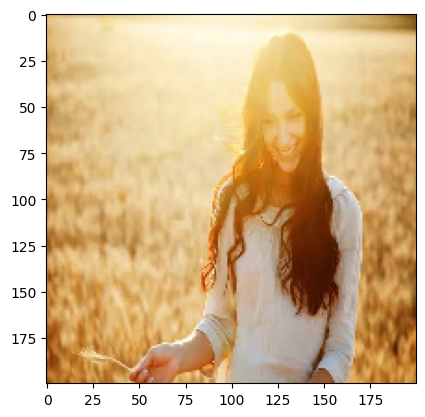

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
I am happy


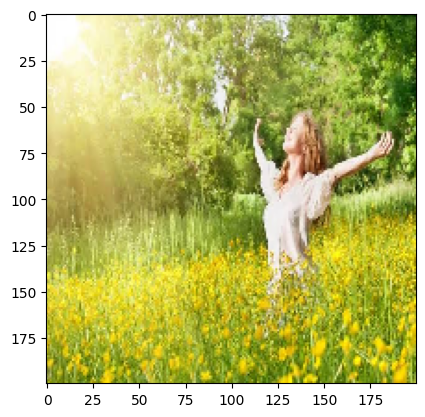

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
I am happy


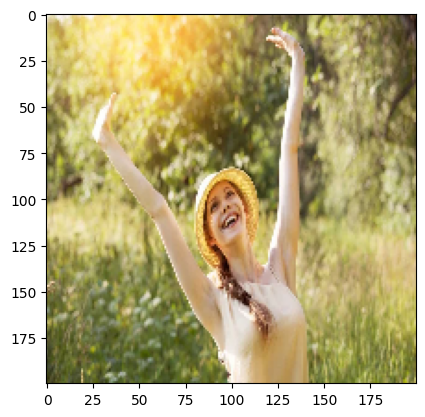

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
I am happy


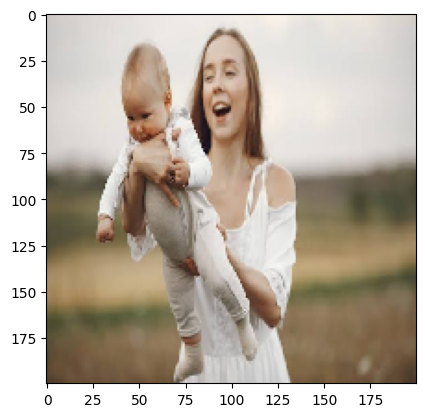

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
I am happy


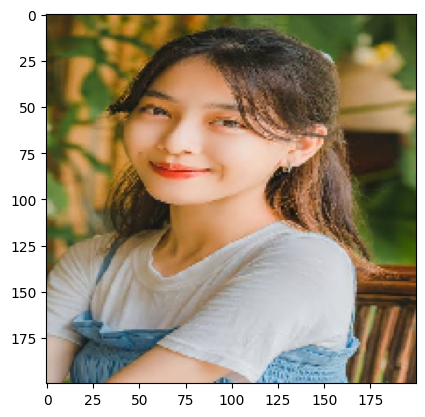

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
I am happy


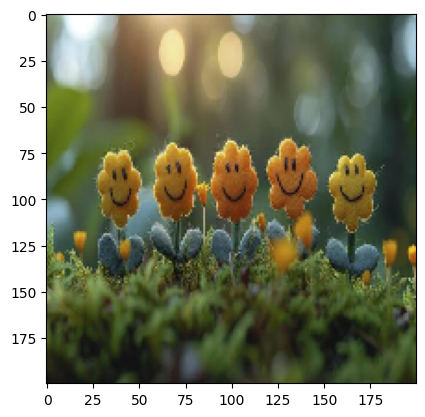

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
I am happy


In [28]:
dir_path = '/content/drive/MyDrive/CNN/testing'
for i in os.listdir(dir_path):
    img = image.load_img(dir_path+ '//'+i, target_size= (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x= np.expand_dims(x,axis=0)
    images = np.vstack([x])
    val = model.predict(images)
    if val == 0:
        print('I am happy')
    else:
        print('I am sad')

In [32]:
def predict_mood(img):
    # Resize image to the target size expected by the model
    img = img.resize((200, 200))
    # Convert PIL image to numpy array
    x = image.img_to_array(img)
    # Expand dimensions to create a batch of 1
    x = np.expand_dims(x, axis=0)
    # Normalize the image data, consistent with ImageDataGenerator rescale value
    # The ImageDataGenerator used 1/200, so we should apply the same here.
    x = x / 200.0

    # Predict using the trained model
    val = model.predict(x)
    if val[0][0] == 0:
        return 'I am happy'
    else:
        return 'I am sad'

In [35]:
from numpy._core.defchararray import title
import gradio as gr
iface = gr.Interface(fn=predict_mood,
                     inputs=gr.Image(type="pil",label="Upload an image"),
                     outputs=gr.Text(label="Predcted Mood"),
                     title = "Mood Classification (HappyNot Happy)",
                     description = "Upload an Image to classify if the person is happy or not happy")
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://57f36a8ed47337b313.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
